In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
import semopy 

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [9]:
data = pd.read_csv("../data/junaeb2.csv");
data.dropna(inplace=True);
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39898 entries, 1 to 41853
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        39898 non-null  int64  
 1   edad        39898 non-null  int64  
 2   imce        39898 non-null  float64
 3   vive_padre  39898 non-null  int64  
 4   vive_madre  39898 non-null  int64  
 5   sk1         39898 non-null  int64  
 6   sk2         39898 non-null  int64  
 7   sk3         39898 non-null  int64  
 8   sk4         39898 non-null  int64  
 9   sk5         39898 non-null  int64  
 10  sk6         39898 non-null  int64  
 11  sk7         39898 non-null  int64  
 12  sk8         39898 non-null  int64  
 13  sk9         39898 non-null  int64  
 14  sk10        39898 non-null  int64  
 15  sk11        39898 non-null  int64  
 16  sk12        39898 non-null  int64  
 17  sk13        39898 non-null  int64  
 18  act_fisica  39898 non-null  float64
 19  area        39898 non-null  in

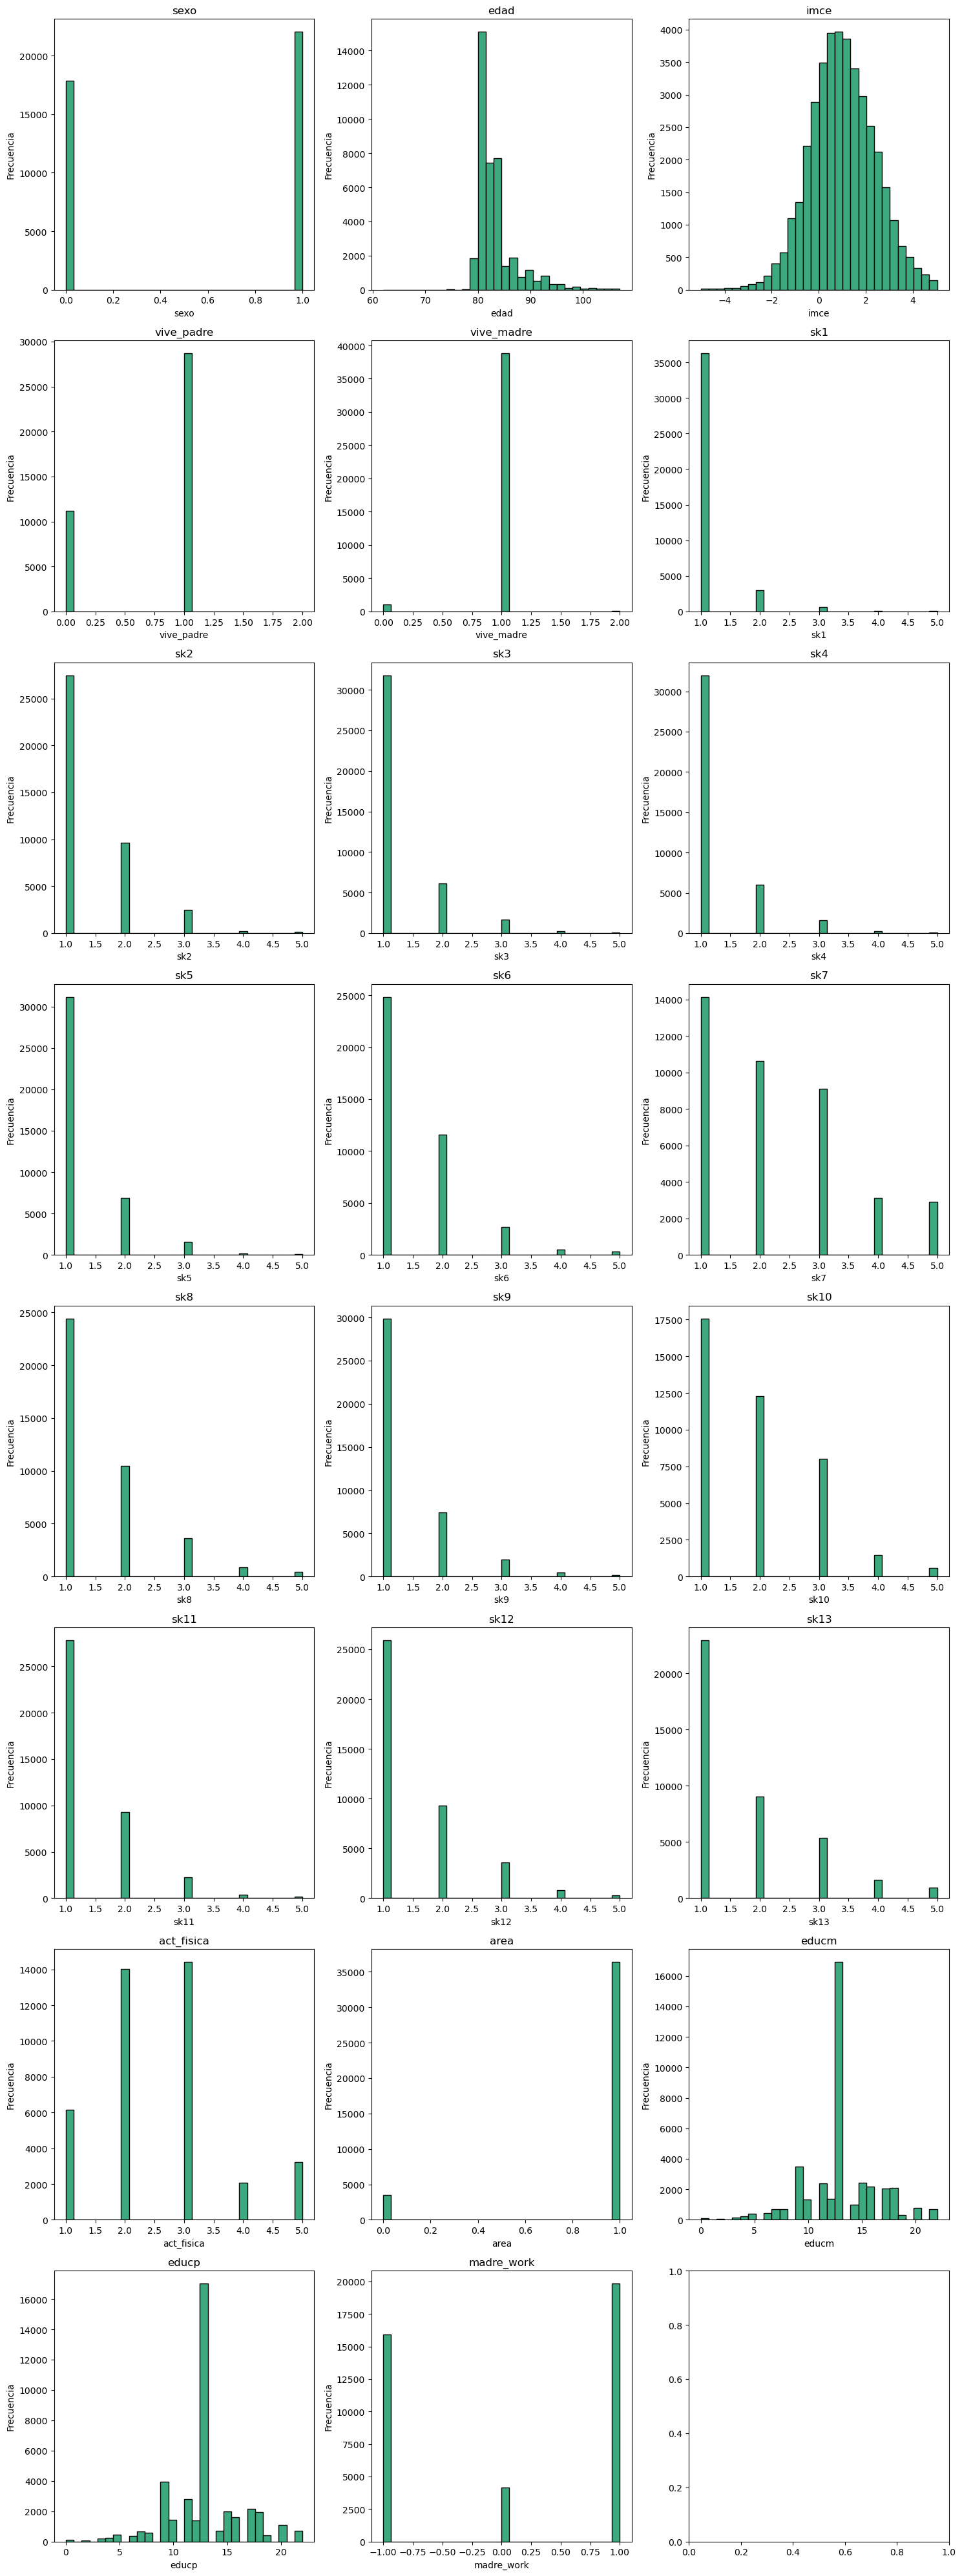

In [10]:
numerical_columns = data.select_dtypes(include='number').columns;
num_columns = len(numerical_columns);
fig, axs = plt.subplots((num_columns + 2) // 3, 3, figsize=(15, (num_columns + 2) // 3 * 5));
for i, column in enumerate(numerical_columns):
    ax = axs[i // 3, i % 3];
    ax.hist(data[column], bins=30, color='#3CA97E', edgecolor='black');
    ax.set_title(f'{column}');
    ax.set_xlabel(column);
    ax.set_ylabel('Frecuencia');
plt.tight_layout();
plt.show()

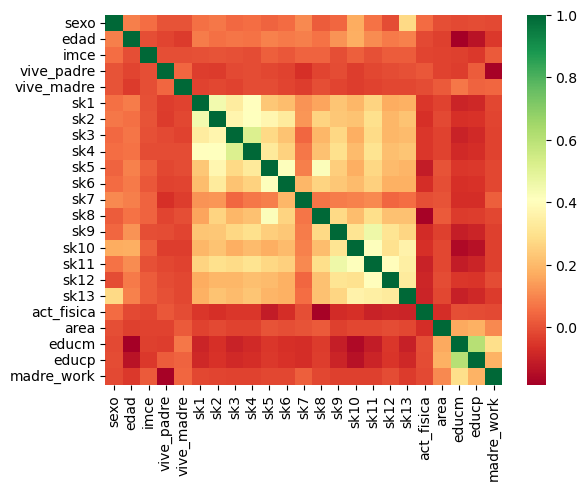

In [11]:
sns.heatmap(data.corr(), cmap='RdYlGn');

2. Usando las variables sk1-sk13 realice un PCA. En particular, identifique los valores propios y determine el numero optimo de componentes. Luego estime y grafique la distribucion de los componentes. Ademas discuta la importancia relativa de las variables sobre cada uno de los componentes estimados. Que se puede concluir de este analisis?

In [12]:
data0 = data.copy()
data_sk = data0[["sk"+str(i) for i in range(1, 14)]];
pca = PCA(n_components=len(data_sk.columns));
pca_features = pca.fit_transform(data_sk);
print(pca.explained_variance_ratio_)

[0.29023744 0.18379003 0.10021546 0.07922673 0.06628868 0.06424966
 0.05160728 0.04410606 0.03240904 0.02941843 0.02473321 0.0209003
 0.01281768]


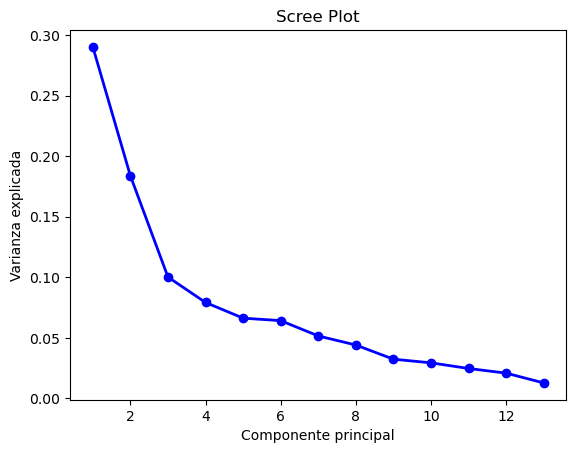

In [13]:
PC_values = np.arange(pca.n_components_) + 1;
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue');
plt.title('Scree Plot');
plt.xlabel('Componente principal');
plt.ylabel('Varianza explicada');
plt.show()

In [14]:
pca_vectors = pd.DataFrame(data = pca.components_)
pca_vectors.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.105446,0.228673,0.171445,0.189575,0.186335,0.250331,0.319635,0.290221,0.248520,0.409348,0.294918,0.294092,0.429746
1,0.005015,0.023283,0.063225,0.052706,0.035437,-0.041748,-0.933450,0.090938,0.080663,0.151374,0.092877,0.148928,0.223235
2,0.083818,0.264013,0.189558,0.196065,0.297209,0.332190,-0.116195,0.466966,0.084999,-0.376812,0.009416,-0.086945,-0.511659
3,0.000739,-0.028808,-0.034733,-0.033641,-0.050616,-0.006470,-0.037272,-0.104653,0.099675,0.711923,0.134608,0.012097,-0.668469
4,0.159874,0.297486,0.334437,0.330050,-0.028306,0.148726,-0.035015,-0.758928,0.084120,-0.161295,0.086777,0.142409,-0.064345


3. Con los resultados de la Pregunta 2, mantenga los primeros 3 componentes principales. Graficamente indique si existen diferencias significativas entre grupos usando las siguientes variables: sexo, area, madre_work y act_fisica. Que puede concluir de los resultados?

In [15]:
pca = PCA(n_components=3);
pca_features = pca.fit_transform(data_sk);

pca_df = pd.DataFrame(data=pca_features,columns=['PC1', 'PC2', 'PC3']);

dfa = pd.merge(data0, pca_df, left_index=True, right_index=True);
dfa.head()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk12,sk13,act_fisica,area,educm,educp,madre_work,PC1,PC2,PC3
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,5.0,0,8.0,8,1,-1.620376,-0.278041,0.015046
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,2.0,1,16.0,12,-1,-0.752432,-2.121658,0.046668
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1.0,1,17.0,15,0,2.245132,-0.052168,0.027883
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,4.0,0,8.0,8,-1,4.230697,1.567886,0.554240
6,1,91,2.75,1,1,1,1,1,2,2,...,2,2,2.0,1,20.0,19,1,2.884315,0.252922,-0.991052


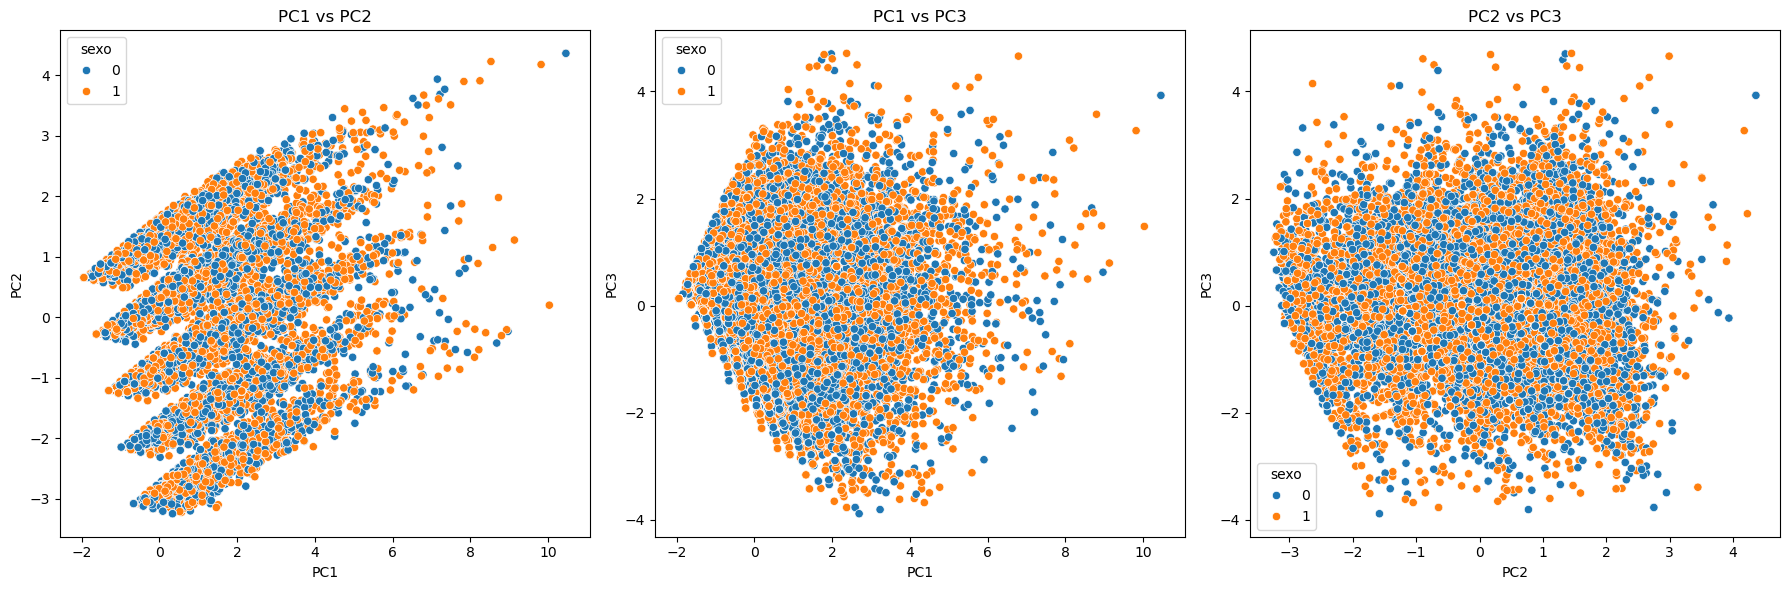

In [16]:
d = "sexo";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar PC1 vs PC2
sns.scatterplot(data=dfa, x='PC1', y='PC2', hue=d, ax=axs[0]);
axs[0].set_title('PC1 vs PC2');
axs[0].set_xlabel('PC1');
axs[0].set_ylabel('PC2');

#Graficar PC1 vs PC3
sns.scatterplot(data=dfa, x='PC1', y='PC3', hue=d, ax=axs[1]);
axs[1].set_title('PC1 vs PC3');
axs[1].set_xlabel('PC1');
axs[1].set_ylabel('PC3');

#Graficar PC2 vs PC3
sns.scatterplot(data=dfa, x='PC2', y='PC3', hue=d, ax=axs[2]);
axs[2].set_title('PC2 vs PC3');
axs[2].set_xlabel('PC2');
axs[2].set_ylabel('PC3');

plt.tight_layout();
plt.show()

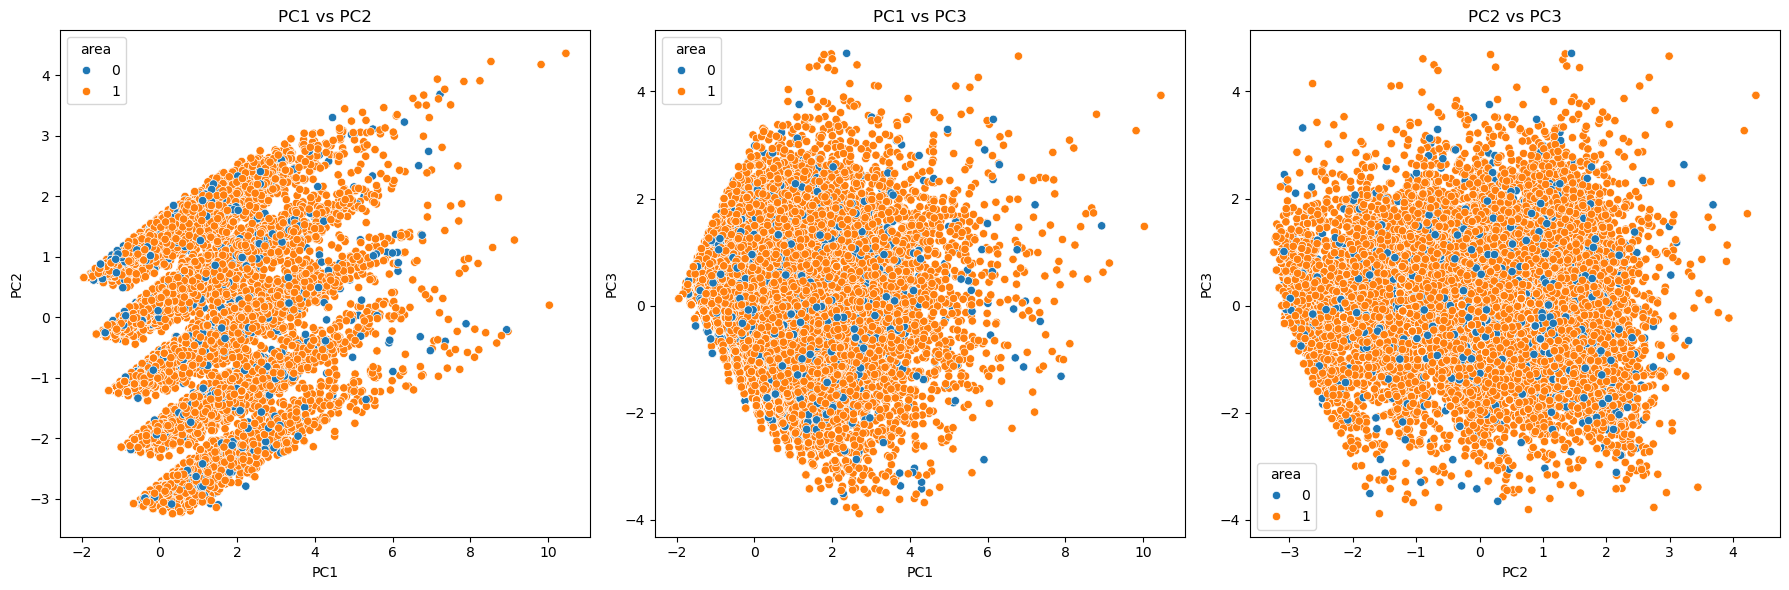

In [17]:
d = "area";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar PC1 vs PC2
sns.scatterplot(data=dfa, x='PC1', y='PC2', hue=d, ax=axs[0]);
axs[0].set_title('PC1 vs PC2');
axs[0].set_xlabel('PC1');
axs[0].set_ylabel('PC2');

#Graficar PC1 vs PC3
sns.scatterplot(data=dfa, x='PC1', y='PC3', hue=d, ax=axs[1]);
axs[1].set_title('PC1 vs PC3');
axs[1].set_xlabel('PC1');
axs[1].set_ylabel('PC3');

#Graficar PC2 vs PC3
sns.scatterplot(data=dfa, x='PC2', y='PC3', hue=d, ax=axs[2]);
axs[2].set_title('PC2 vs PC3');
axs[2].set_xlabel('PC2');
axs[2].set_ylabel('PC3');

plt.tight_layout();
plt.show()

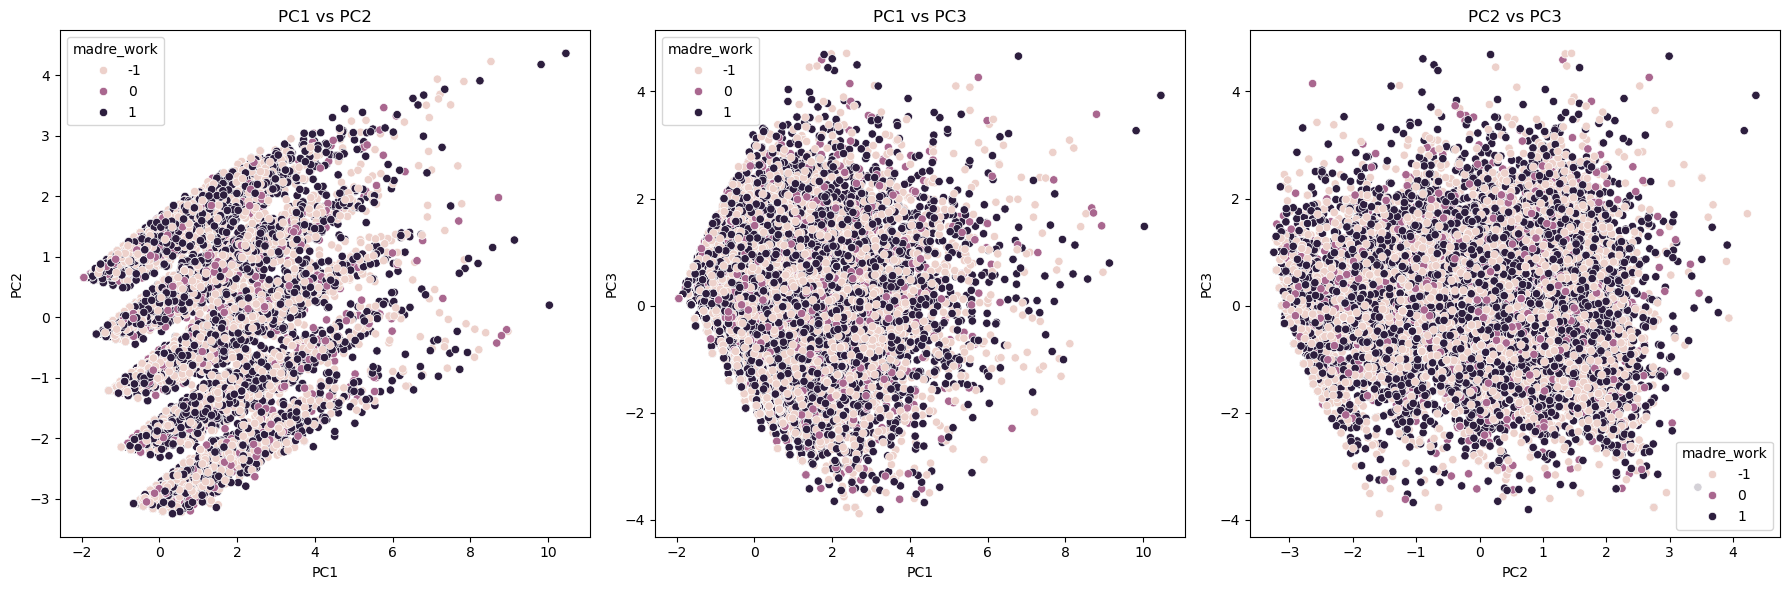

In [18]:
d = "madre_work";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar PC1 vs PC2
sns.scatterplot(data=dfa, x='PC1', y='PC2', hue=d, ax=axs[0]);
axs[0].set_title('PC1 vs PC2');
axs[0].set_xlabel('PC1');
axs[0].set_ylabel('PC2');

#Graficar PC1 vs PC3
sns.scatterplot(data=dfa, x='PC1', y='PC3', hue=d, ax=axs[1]);
axs[1].set_title('PC1 vs PC3');
axs[1].set_xlabel('PC1');
axs[1].set_ylabel('PC3');

#Graficar PC2 vs PC3
sns.scatterplot(data=dfa, x='PC2', y='PC3', hue=d, ax=axs[2]);
axs[2].set_title('PC2 vs PC3');
axs[2].set_xlabel('PC2');
axs[2].set_ylabel('PC3');

plt.tight_layout();
plt.show()

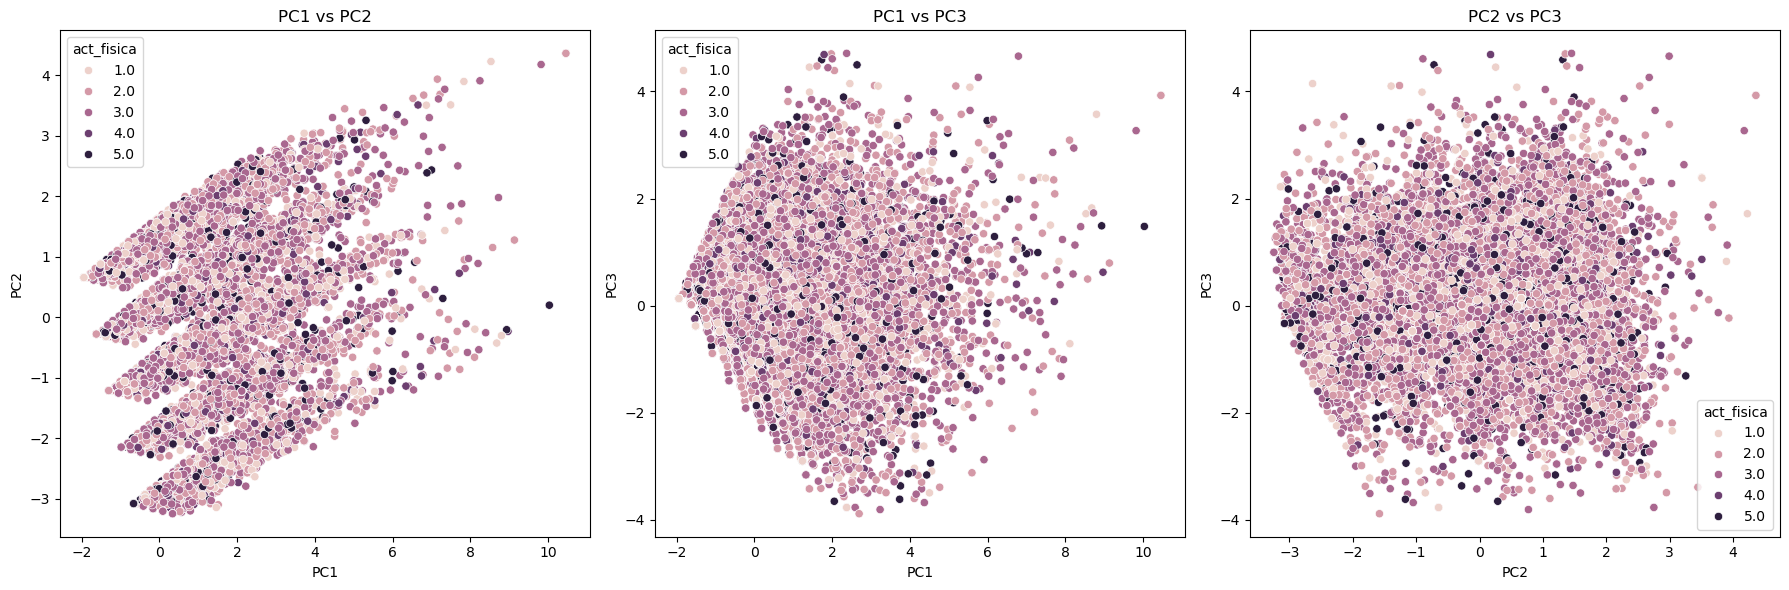

In [19]:
d = "act_fisica";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar PC1 vs PC2
sns.scatterplot(data=dfa, x='PC1', y='PC2', hue=d, ax=axs[0]);
axs[0].set_title('PC1 vs PC2');
axs[0].set_xlabel('PC1');
axs[0].set_ylabel('PC2');

#Graficar PC1 vs PC3
sns.scatterplot(data=dfa, x='PC1', y='PC3', hue=d, ax=axs[1]);
axs[1].set_title('PC1 vs PC3');
axs[1].set_xlabel('PC1');
axs[1].set_ylabel('PC3');

#Graficar PC2 vs PC3
sns.scatterplot(data=dfa, x='PC2', y='PC3', hue=d, ax=axs[2]);
axs[2].set_title('PC2 vs PC3');
axs[2].set_xlabel('PC2');
axs[2].set_ylabel('PC3');

plt.tight_layout();
plt.show()

4. A partir del mismo set de variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y las variables que se asocian a cada factor. Tambien discuta si existen variables que no son informativas (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [20]:
#Debe voltearse sk7
temp_map = {1: -1, 2: -2, 3: -3, 4: -4, 5: -5};
data_sk["sk7"] = data_sk["sk7"].map(temp_map).replace({-1: 5, -2: 4, -3: 3, -4: 2, -5: 1});

C:\Users\juanc\AppData\Local\Temp\ipykernel_4184\2633433265.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sk["sk7"] = data_sk["sk7"].map(temp_map).replace({-1: 5, -2: 4, -3: 3, -4: 2, -5: 1});


In [21]:
fa = FactorAnalyzer(rotation='varimax').fit(data_sk);
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.168627, 0.546201, 0.150317],
       [0.169615, 0.521612, 0.350736],
       [0.186998, 0.589452, 0.158949],
       [0.194442, 0.673242, 0.193061],
       [0.117685, 0.213396, 0.729676],
       [0.173521, 0.206983, 0.484532],
       [-0.072735, -0.079992, -0.144848],
       [0.264605, 0.101318, 0.473972],
       [0.497989, 0.214232, 0.204119],
       [0.553557, 0.120413, 0.129000],
       [0.660687, 0.213328, 0.202922],
       [0.524942, 0.116998, 0.141850],
       [0.496302, 0.147668, 0.133146]])

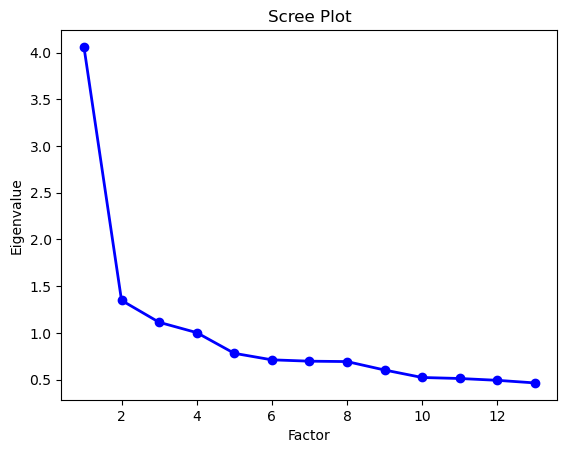

In [22]:
values = np.arange(1,14);
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues());
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue');
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [23]:
print(semopy.efa.explore_cfa_model(data_sk, pval=0.05));

eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk6 + sk7
eta3 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk8 + sk12
eta4 =~ sk11 + sk12 + sk13



5. Con los resultados obtenidos en la Pregunta 4, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre todas las variables. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores. 

In [24]:
mod = '''
eta1 =~ sk11 + sk9 + sk10 + sk12            #Interés por aprender
eta2 =~ sk6 + sk7                           #Amabilidad
eta3 =~ sk4 + sk2 + sk5 + sk3 + sk1 + sk8   #Expresa sus sentimientos
'''
#No se incluye sk13 porque quedó solita

model = semopy.Model(mod);
out = model.fit(data_sk);
print(out);

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.275
Number of iterations: 31
Params: 0.803 1.001 0.824 -0.531 1.121 0.842 0.907 0.559 0.967 0.281 0.219 0.244 0.221 0.566 1.395 0.103 0.222 0.189 0.195 0.642 0.464 0.146 0.324 0.135 0.261 0.133 0.126


In [25]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,10988.524996,0.0,101886.742668,0.892581,0.89215,0.860429,0.89215,0.860987,0.073317,53.449169,285.489369,0.275415


In [26]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk11,~,eta1,1.000000,0.756730,-,-,-
1,sk9,~,eta1,0.802723,0.611957,0.008216,97.698486,0.0
2,sk10,~,eta1,1.001097,0.537802,0.011333,88.336276,0.0
3,sk12,~,eta1,0.824147,0.525761,0.00951,86.665095,0.0
4,sk6,~,eta2,1.000000,0.770559,-,-,-
5,sk7,~,eta2,-0.530850,-0.247988,0.01891,-28.072562,0.0
6,sk4,~,eta3,1.000000,0.660278,-,-,-
7,sk2,~,eta3,1.121301,0.655251,0.010818,103.648583,0.0
8,sk5,~,eta3,0.841901,0.566296,0.0091,92.514257,0.0
9,sk3,~,eta3,0.907408,0.593833,0.009439,96.135984,0.0


6. Finalmente, implemente un SEM completo usando la estructura propuesta en la Pregunta 5. En particular, estime un modelo donde los factores explican el nivel de actividad fisica, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para explicar los factores latentes. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase. Que puede concluir en base a sus resultados?

In [27]:
mod_cf = '''
eta1 =~ sk11 + sk9 + sk10 + sk12            #Interés por aprender
eta2 =~ sk6 + sk7                           #Amabilidad
eta3 =~ sk4 + sk2 + sk5 + sk3 + sk1 + sk8   #Expresa sus sentimientos

act_fisica =~ eta1 + eta2 + eta3 + sexo + edad + imce + area + madre_work + sk13
eta1 ~ educm + educp
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(data);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.670
Number of iterations: 51
Params: 0.815 1.087 0.857 0.589 1.098 0.801 0.909 0.557 0.936 0.828 0.711 0.222 1.788 0.074 -0.022 -0.109 1.271 -0.008 -0.005 0.246 0.216 0.571 0.885 0.102 1.902 0.184 0.612 0.459 0.062 0.285 0.080 0.173 0.067 0.226 14.957 1.385 0.254 0.209 0.710 0.239 0.174


In [28]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,169,192,26732.642,0.0,145078.778811,0.816659,0.815737,0.79066,0.815737,0.791708,0.062767,80.659951,433.017291,0.670025


In [29]:
model_cfa.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,eta1,~,act_fisica,1.000000,0.847949,-,-,-
1,eta2,~,act_fisica,0.827638,0.639041,0.011952,69.244285,0.0
2,eta3,~,act_fisica,0.710992,0.765050,0.009451,75.228268,0.0
3,eta1,~,educm,-0.007631,-0.052159,0.000891,-8.562321,0.0
4,eta1,~,educp,-0.004831,-0.033872,0.000868,-5.562715,0.0
5,sk11,~,eta1,1.000000,0.732921,-,-,-
6,sk9,~,eta1,0.814709,0.600692,0.008309,98.048946,0.0
7,sk10,~,eta1,1.086530,0.564388,0.01166,93.186542,0.0
8,sk12,~,eta1,0.857352,0.528642,0.009731,88.105364,0.0
9,sk6,~,eta2,1.000000,0.731416,-,-,-


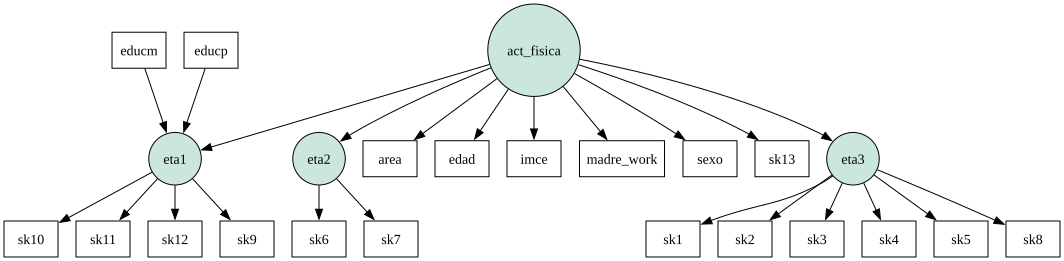

In [30]:
semopy.semplot(mod_cf, "semmodel.png")